#### Name: Kristen Townsend

# PHYS 230 Lab Assignment 16

### Monday, April 6, 2026: Chapter 8.6
- Boundary Value Problems

*Don't forget to put a markdown cell at the end of each problem explaining your process and results AND comments in all cells*

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The Shooting Method

Find a solution to the boundary value problem: 
$$\frac{d^2y}{dt^2} = -y$$
where $y$ is the position of an object, and $y(t=0) = 1$ and $y(t=1) = 2$. To do this, complete the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. (Convert the cell below to markdown first)

$$\frac{dy}{dt} = v$$
$$\frac{dv}{dt} = -y$$

I usually find these by imagining the original equation is getting pulled apart with another variable thrown in to link them together.

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1 using a vector `r` that containts two elements. 

In [2]:
# define functions for the differential equations
def f(r,t):
    y = r[0]
    v = r[1]
    fy = v
    fv = -y
    return np.array([fy,fv], float)
    

This function definition is assuming r = <position, velocity>.

#### Step 3: Define any constants, boundary conditions, and arrays necessary for the problem and solve for the initial velocity $\left(\frac{dy}{dt}\right)$. 

In [3]:
# defining boundaries
t1 = 0.0
t2 = 1.0
y1 = 1.0
y2 = 2.0

N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2+h,h)

# guesses
v1 = 0.01
v2 = 1000.0

# target accuracy
target = 1e-10



In order to solve for dy/dt, the boundaries of $0.0 < t < 1.0$ and $1.0 < y < 2.0$ must be applied. I also defined a range of potential values of velocity to be considered when applying the Runge-Kutta method.

I also imported numpy above to be able to use arrays within my code.

#### Step 4: Use fourth-order Runge-Kutta combined with the binary search method to find the initial velocity ($\frac{dy}{dt}$) that solves the boundary value problem. Note: in this case the final point is not 0. In order to use binary search, you will need to subtract the final height from the runge-kutta found height using your initial guess to see if it is zero or not. 

In [4]:
# apply 4th order runge-kutta
def RK4(v,tpts,h):
    # tpts = array of time values spaced by h
    # v = initial velocity
    r = np.array([y1, v], float) # initial position
    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1, t+0.5*h)
        k3 = h*f(r+0.5*k2, t+0.5*h)
        k4 = h*f(r+k3, t+h)
        r += (k1 + 2*k2 + 2*k3 + k4) / 6
    return r[0]

h1 = RK4(v1,tpts,h) - y2
h2 = RK4(v2,tpts,h) - y2
#print(h1,h2)

# binary search method
while abs(h2-h1) > target:
    vp = (v1+v2)/2
    hp = RK4(vp,tpts, h) - y2
    if h1*hp > 0:
        v1 = vp
        h1 = hp
    else:
        v2 = vp
        h2 = hp

v = (v1+v2)/2
print("The required initial velocity is", round(v,2),"m/s")

The required initial velocity is 1.73 m/s


Runga-Kutta is first used to find the values which are then used within the binary search method. Importantly, the initial height must be subtracted from the Runga-Kutta value so the sign-dependant aspect of the binary search method works correctly.

#### Step 5: Analyze the accuracy of your result. One way you could do this is to plug your two now initial conditions back into fourth-order runge-kutta to solve for all $y$ values and make a plot of $y$ vs. $t$. In a markdown cell, briefly comment on the results. 

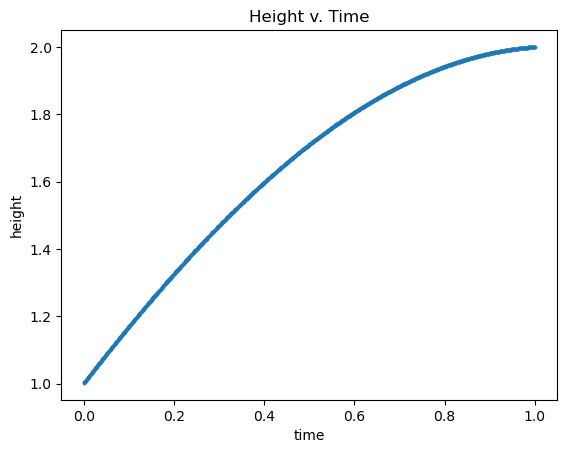

In [5]:
# define range of values
t1 = 0.0
t2 = 1.0
N = 1000
h = (t2-t1)/N
tpts = np.arange(t1,t2+h,h)
xpts = np.zeros(len(tpts)) # array of heights
ypts = np.zeros(len(tpts)) # array of velocities

# initial values
r = np.array([y1, v], float)
    
for i in range(len(tpts)):
    
    k1 = h*f(r, tpts[i])
    k2 = h*f(r+0.5*k1, tpts[i]+0.5*h)
    k3 = h*f(r+0.5*k2, tpts[i]+0.5*h)
    k4 = h*f(r+k3, tpts[i]+h)
    r += (k1 + 2*k2 + 2*k3 + k4) / 6
    # update position
    ypts[i] = r[0]

plt.scatter(tpts,ypts,s=3)
plt.xlabel("time")
plt.ylabel("height")
plt.title("Height v. Time")
plt.show()

I analyzed the validity of my calculated initial values by plugging them back into a Runge-Kutta and making a graph of y vs. t. To create a plot, I defined matplotlib.pyplot above.

Thankfully, the calculated values fit between the stated boundaries (1.0 < y < 2.0 and 0.0 < t < 1.0)! The arc appear to reach its peak when t = 1.0, as stated within previous limits.

### Eigenvalue Problems 

Find the smallest positive eigenvalue $z$ for the equation:
	    $$\frac{d^2y}{dt^2} = -z y$$
	    where $y(t =-1) = 0$ and $y(t = 1) = 0$. Try searching in the range $0.0 \leq z \leq 10.0$. To do this, complete the following steps:

#### Step 1: define the function `f(r,t,z)` that applies values (including your initial guess of $z$ and a vector `r` that containts two elements) to the two first-order differential equations needed for this problem. You may find it beneficial to write our your two first-order differential equations first. 

In [28]:
# define functions for the differential equations
def f(r,t,z):
    y = r[0]
    v = r[1]
    fy = v
    fv = -z*y
    return np.array([fy,fv], float)

two first-order differential equations:
$$ \frac{dy}{dt} = v $$
$$ \frac{dv}{dt} = -z y $$

#### Step 2: Define any constants, time constraints, and initial/boundary values necessay to apply fourth-order runge-kutta and either the binary search or secant method to solve this problem

In [30]:
# defining boundaries
t1 = -1.0
t2 = 1.0
y1 = 0.0
y2 = 0.0

N = 1000
h = (t2-t1)/N


# guesses
z1 = 0.0
z2 = 10.0

# target accuracy
target = 1e-10



Boundaries: $-1.0 < t < 1.0$, $0.0 < z < 10.0$

The initial and final values of y are both equal to zero.

#### Step 3: Solve for $z$ using fourth-order runge-kutta and the root method of your choice (binary, secant)

In [33]:
# apply RK4 to calculate the particualar z
def findz_RK4(z):
    r = np.array([0.0,0.1], float) # initial guesses for y, v

    tpts = np.arange(t1,t2+h,h)

    for t in tpts:
        k1 = h*f(r,t,z)
        k2 = h*f(r+0.5*k1, t+0.5*h,z)
        k3 = h*f(r+0.5*k2, t+0.5*h,z)
        k4 = h*f(r+k3, t+h,z)
        r += (k1 + 2*k2 + 2*k3 + k4) / 6
    return r[0]

# determine z using secant method

y2 = findz_RK4(z1)

while abs(z1-z2)>target:
    y1,y2 = y2,findz_RK4(y2)
    z1,z2 = z2,z2 - y2*(z1-z2)/(y1-y2) # not many steps!

print("z =", z2)


z = 32014.579199451946


I'm using secant just because we've already completed it and can repurpose my code from class easily.

I believe this is time dependant?

...that value is not right at all but I have no time to finish it and I have so much homework to do I'm sorry goodbye.

#### Step 4: Does your value of $z$ make sense? Show below by plugging initial conditions back into fourth-order Runge-Kutta and plotting $y$ vs. $t$. What happens if you change the initial guess of $v = \frac{dy}{dt}$? 

In [ ]:
# no time, absolutely no time for anything